In [1]:
# load important libraries    
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# from scipy.integrate import odeint
# from scipy.optimize import minimize
#import pickle
#import xarray as xr
#from itertools import product
import seaborn as sns

In [2]:
#import functions
from model_eqns_scenario_2 import malaria_model
from parameter_values_scenario import params

In [3]:
#Read data
Macapa_data_2019 = pd.read_csv('./data/Macapa_data_2019.csv')
Manaus_data_2019 = pd.read_csv('./data/Manaus_data_2019.csv')

In [4]:
Macapa_data_2019.iloc[0]
#Manaus_data_2019.iloc[0]

date               2019-01-01
Precipitacao              0.0
Temp.Comp.Media          23.8
n                           3
Sem_Ano                 19/01
Name: 0, dtype: object

In [5]:

Temperature_urban = Macapa_data_2019['Temp.Comp.Media']
Temperature_rural = Manaus_data_2019['Temp.Comp.Media']

Rainfall_urban = Macapa_data_2019['Precipitacao']
Rainfall_rural = Manaus_data_2019['Precipitacao']

Text(0.5, 1.0, 'Manaus malaria for 2019')

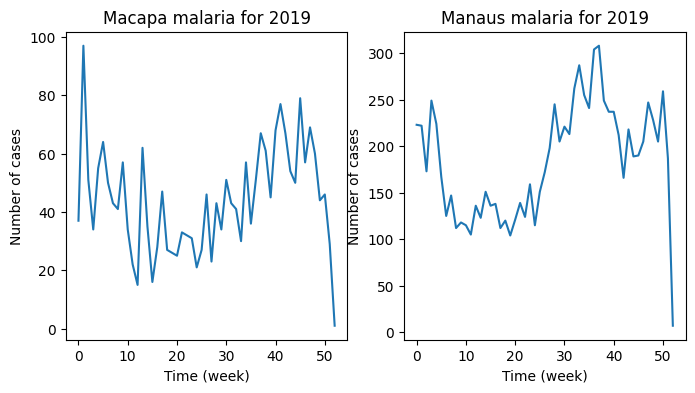

In [6]:
Macapa_data_2019 = Macapa_data_2019.groupby('Sem_Ano')['n'].sum().reset_index()
Manaus_data_2019 = Manaus_data_2019.groupby('Sem_Ano')['n'].sum().reset_index()

fig, axs = plt.subplots(1,2, figsize = (8,4))
axs[0].plot(Macapa_data_2019['n'])
axs[0].set_xlabel('Time (week)')
axs[0].set_ylabel('Number of cases')
axs[0].set_title ('Macapa malaria for 2019')
axs[1].plot(Manaus_data_2019['n'])
axs[1].set_xlabel('Time (week)')
axs[1].set_ylabel('Number of cases')
axs[1].set_title ('Manaus malaria for 2019')

In [7]:

# DAYS = 365
# t = np.arange(DAYS)
# Defining the time range
initial_time = 1
final_time = len(Temperature_urban)  
tempo = np.arange(initial_time, final_time + 1)  

#Defining the initial condition Macapa

Nh_U= 5.03327e5
Nm_U = Nh_U*params['m_U']
init_U = 306  #Model simulation at the end of 2018


#Defining the initial condition Manaus
Nh_R = 2.2e6 
Nm_R = Nh_R*params['m_R']
init_R = 5000 # model simulation at the end of 2018
inicial = {'tempo':1, 'Sh_UU' : 1-init_U/Nh_U, 'Sh_UR' : 0, 'Ih_UU' : init_U/Nh_U, 'Ih_UR' : 0, 'L_UU' : 0, 'L_UR' : 0, 'P_UU' : 0, 'P_UR' : 0, 'Sm_U' : params['m_U'], 
             'Im_U' : 0, 'Cases_U' : 0, 'Nm_U' : Nm_U, 'Nh_U' : 1,   'Sh_RR' : 1-init_R/Nh_R, 'Sh_RU' :0, 'Ih_RR' : init_R/Nh_R, 'Ih_RU' : 0,  'L_RR' : 0, 'L_RU' : 0,
            'P_RR' : 0, 'P_RU' : 0, 'Sm_R' : params['m_R'], 'Im_R' : 0, 'Cases_R' : 0 , 'Nm_R' : Nm_R , 'Nh_R' : 1}

#Creating the results matrix
df_sim = pd.DataFrame({"tempo": tempo})
vars = ["Sh_UU", "Sh_UR", "Ih_UU", "Ih_UR", "L_UU", "L_UR", "P_UU", "P_UR", "Sm_U", "Im_U", "Cases_U", "Nm_U",  "Nh_U", 
        "Sh_RR", "Sh_RU", "Ih_RR", "Ih_RU", "L_RR", "L_RU", "P_RR", "P_RU", "Sm_R", "Im_R",  "Cases_R" , "Nm_R", "Nh_R"]
df_sim[vars] = np.nan # Initialize with NaN values
df_sim.loc[0] = inicial # Set the first row with initial conditions

In [8]:
def build_mobility(sid):
    """
    Return mobility dict: m_RU1_t (array), m_RU2 (scalar return rate)
    m_RU1_base chosen small (per-day probability of leaving)
    """
    m_RU1_base = 0.003  # per day baseline rural->urban outflow
    m_UR1_base = 0.003  # per day baseline rural->urban outflow
    
    tau_base = 10.0
    m_RU2_base = 1.0 / tau_base
    m_UR2_base = 1.0 / tau_base
    
    m_RU1_t = np.full(final_time, m_RU1_base)
    m_UR1_t = np.full(final_time, m_UR1_base)
    m_RU2 = m_RU2_base
    m_UR2 = m_UR2_base

    if sid == 0:
        # No mobility
        m_RU1_t = 0*np.full(final_time, m_RU1_base)
        m_UR1_t = 0*np.full(final_time, m_UR1_base)
        m_RU2 = 0*m_RU2_base
        m_UR2 = 0*m_UR2_base

    elif sid == 1:
        # Only from Rural to urban mobility
        m_RU1_t = np.full(final_time, m_RU1_base)
        m_UR1_t = 0*np.full(final_time, m_UR1_base)
        m_RU2 = m_RU2_base
        m_UR2 = 0*m_UR2_base
    elif sid == 2:
        # Only from Urban to rural mobility
        m_RU1_t = 0*np.full(final_time, m_RU1_base)
        m_UR1_t = np.full(final_time, m_UR1_base)
        m_RU2 = 0*m_RU2_base
        m_UR2 = m_UR2_base
    elif sid == 3:
        # Mobility from both regions
        m_RU1_t = np.full(final_time, m_RU1_base)
        m_UR1_t = np.full(final_time, m_UR1_base)
        m_RU2 = m_RU2_base
        m_UR2 = m_UR2_base
        
    elif sid == 4:
        # S1: urbanization surge: outflow x2, tau=60
        
        m_RU1_t = 1.5*np.full(final_time, m_RU1_base)
        m_UR1_t = np.full(final_time, m_UR1_base)
        m_RU2 = m_RU2_base
        m_UR2 = m_UR2_base
        
    elif sid == 5:
        # S1: Rural campaign surge: outflow x2, tau=60
        
        m_RU1_t = np.full(final_time, m_RU1_base)
        m_UR1_t = 1.5*np.full(final_time, m_UR1_base)
        m_RU2 = m_RU2_base
        m_UR2 = m_UR2_base
        
    elif sid == 6:
        
        # S5: seasonal pulses aligned to rainy peaks, tau=14d (displacement due to heavy rain)
        m_UR1_t = np.full(final_time, m_UR1_base)
        m_RU2 = m_RU2_base
        m_UR2 = m_UR2_base
        window = 30
        roll = pd.Series(Rainfall_rural).rolling(window, center=True).mean().bfill().ffill()
        peaks = np.argsort(roll.values)[-3:]  # indices for 3 strongest windows
        for p in peaks:
            start = max(0, p - window // 2)
            end = min(final_time, p + window // 2)
            m_RU1_t[start:end] = 1.5 * m_RU1_base
    
    elif sid == 7:
        # S6: mobility surge from urban to rural during summar 
        m_RU1_t = np.full(final_time, m_RU1_base)
        m_RU2 = m_RU2_base
        m_UR2 = m_UR2_base

        window = 30
        roll = pd.Series(Temperature_rural).rolling(window, center=True).mean().bfill().ffill()
        peaks = np.argsort(roll.values)[-3:]  # indices for 3 strongest windows
        for p in peaks:
            start = max(0, p - window // 2)
            end = min(final_time, p + window // 2)
            m_UR1_t[start:end] = 1.5 * m_UR1_base
        
        
    elif sid == 8:
        # S7: pulses like S5 but shifted +28 days
        m_UR1_t = np.full(final_time, m_UR1_base)
        m_RU2 = m_RU2_base
        m_UR2 = m_UR2_base
        
        window = 21
        roll = pd.Series(Rainfall_rural).rolling(window, center=True).mean().bfill().ffill()
        peaks = np.argsort(roll.values)[-3:] + 28
        for p in peaks:
            if p < 0 or p >= final_time:
                continue
            start = max(0, p - window // 2)
            end = min(final_time, p + window // 2)
            m_RU1_t[start:end] = 1.5 * m_RU1_base
    else:
        raise ValueError("Unknown scenario id")
    
    return {"m_UR1_t": m_UR1_t, "m_UR2": m_UR2, "m_RU1_t": m_RU1_t, "m_RU2": m_RU2}

In [9]:
# def apply_urban_container_boost(climate_series, sid, boost=1.8, dry_thresh=5.0):
#     """
#     For scenario 4 only: increase urban effective rainfall slightly during dry days
#     to mimic container breeding compensation.
#     """
#     if sid != 4:
#         return climate_series
#     R_u = climate_series["R_u"].copy()
#     low = R_u < dry_thresh
#     # modest additive boost on dry days
#     R_u[low] = R_u[low] + (boost - 1.0) * dry_thresh * 0.7
#     out = climate_series.copy()
#     out["R_u"] = R_u
#     return out

In [10]:
scenario_names = {
    0: "No mobility (base case)",
    1: "Only rural to urban (0.3% daily)",
    2: "Only urban to rural ((0.3% daily))",
    3: "Mobility from both regions ((0.5% daily))",
    4: "Increased (50%) R-> U mobility ",
    5: "Increased (50%) U-> R mobility ",
    6: "Increased (50%) R-> U mobility (displacement due to heavy rain)",
    7: "Increased (50%) U-> R mobility (hot days)",
    8: "Increased (50%) R-> U mobility (after rainy season)",   
}
colors = {
    0: "black",
    1: "red",
    2: "blue",
    3: "green",
    4: "orange",
    5: "purple",
    6: "brown",
    7: "pink",
    8: "gray",
}

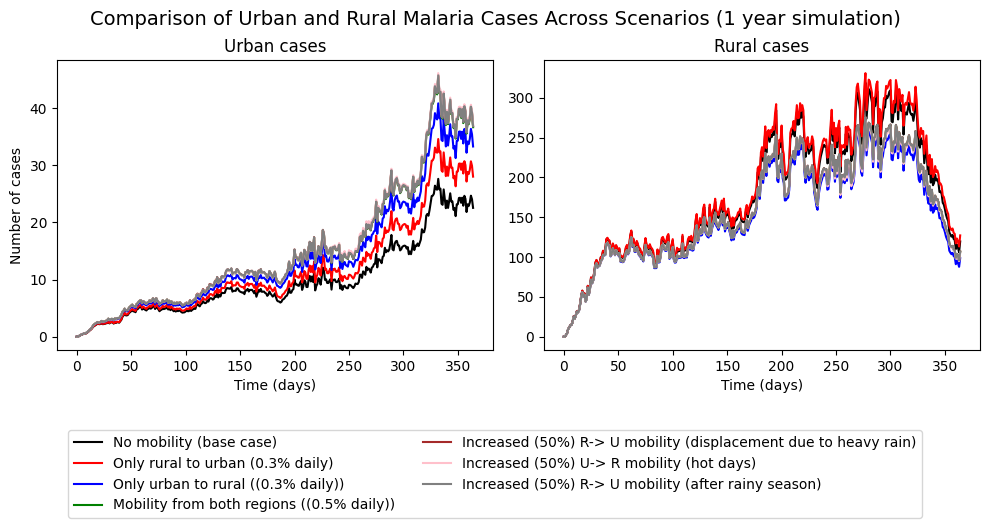

In [11]:
clim = {"T_u": Temperature_urban.copy(), "T_r": Temperature_rural.copy(), "R_u": Rainfall_urban.copy(), "R_r": Rainfall_rural.copy()}
all_dfs = []
current_params = params.copy()

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
cummulative_results = {}

selected_scenarios = [0,1,2,3,6,7,8]
for sid in selected_scenarios:
    
    #clim = build_climate_series(sid)
    #clim = apply_urban_container_boost(clim, sid)
    mob = build_mobility(sid)
    
    df_res = malaria_model(df_sim, clim, mob, current_params) 

    if sid == 0:
        base_urban_cum_case = np.sum(df_res['Cases_U']*Nh_U)
        base_rural_cum_case = np.sum(df_res['Cases_R']*Nh_R)
    rural_cange = (base_rural_cum_case - np.sum(df_res['Cases_R']*Nh_R)) / base_rural_cum_case * 100
    urban_change = (base_urban_cum_case - np.sum(df_res['Cases_U']*Nh_U)) / base_urban_cum_case * 100

    cummulative_results[sid] = {
        'change_urban': urban_change,
        'change_rural': rural_cange,
        'Urban cum': np.sum(df_res['Cases_U']*Nh_U),
        'Rural cum': np.sum(df_res['Cases_R']*Nh_R)
    }

    axs[0].plot(df_res['Cases_U']*Nh_U, color = colors[sid], label=scenario_names[sid])
    axs[1].plot(df_res['Cases_R']*Nh_R,color = colors[sid])
    
    df_res["scenario_id"] = sid
    df_res["scenario_name"] = scenario_names[sid]
    all_dfs.append(df_res)
    # # Save per-scenario CSV
    # path = f"scenario_{sid}.csv"
    # df_res.to_csv(path, index=False)
    # print(f"Saved {path}")
axs[0].set_title('Urban cases')
axs[0].set_xlabel('Time (days)')
axs[0].set_ylabel('Number of cases')

axs[1].set_title('Rural cases')
axs[1].set_xlabel('Time (days)')
#axs[1].set_ylabel('Number of cases')


# Shared legend
handles, labels = axs[0].get_legend_handles_labels()

fig.legend(
    handles, labels,
    loc='lower center',
    ncol=2,
    bbox_to_anchor=(0.5, -0.05)
)
fig.suptitle("Comparison of Urban and Rural Malaria Cases Across Scenarios (1 year simulation)", fontsize=14)
plt.tight_layout()
plt.subplots_adjust(top=0.88, bottom=0.3)
# Save combined results
df_all = pd.concat(all_dfs, ignore_index=True)

# df_all.to_csv("malaria_5_scenarios_results.csv", index=False)
# print("Saved malaria_5_scenarios_results.csv")

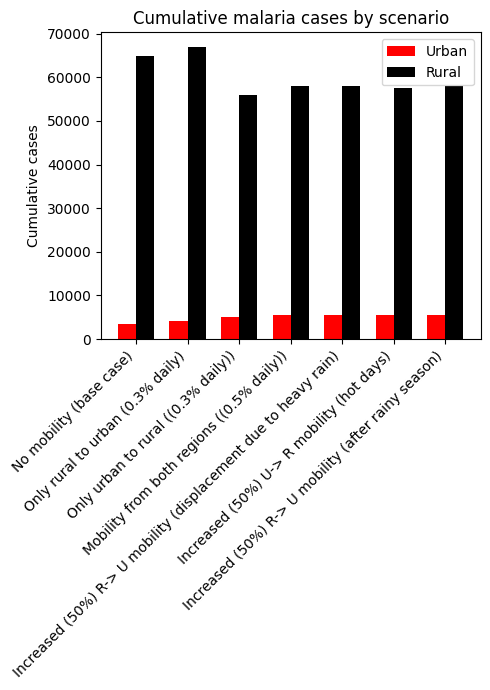

In [12]:
# Prepare data

urban = [cummulative_results[sid]['Urban cum'] for sid in selected_scenarios]
rural = [cummulative_results[sid]['Rural cum'] for sid in selected_scenarios]
labels = [scenario_names[sid] for sid in selected_scenarios]

x = np.arange(len(labels))  # positions
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(5,7))
ax.bar(x - width/2, urban, width, label='Urban', color='red')
ax.bar(x + width/2, rural, width, label='Rural', color='black')

ax.set_ylabel('Cumulative cases')
ax.set_title('Cumulative malaria cases by scenario')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

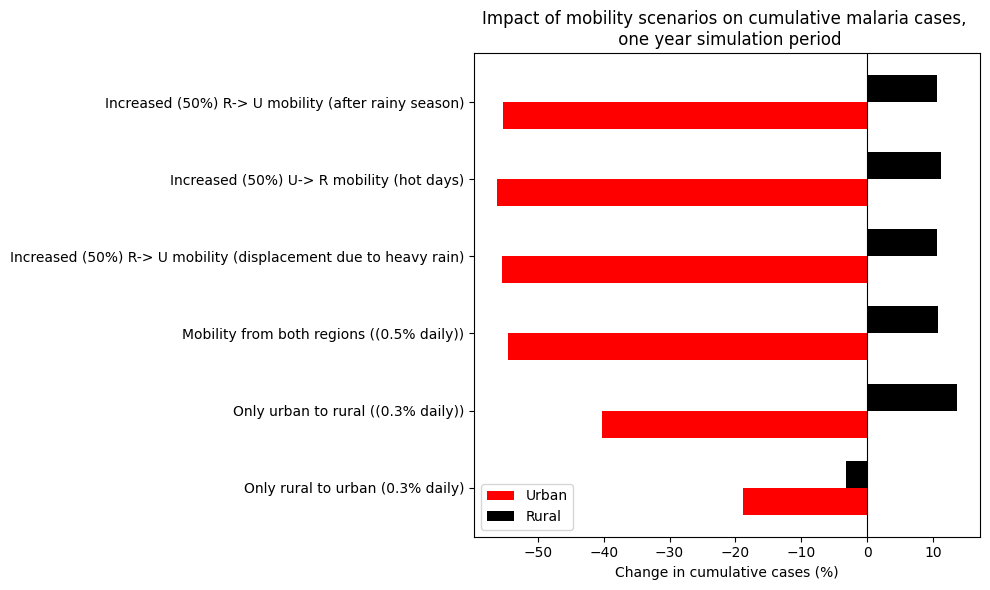

In [13]:
# Prepare data
scenario_ids = selected_scenarios[1:]  # skip 0 because it's the base
labels = [scenario_names[sid] for sid in scenario_ids]

urban_changes = [cummulative_results[sid]['change_urban'] for sid in scenario_ids]
rural_changes = [cummulative_results[sid]['change_rural'] for sid in scenario_ids]

y = np.arange(len(labels))  # positions
height = 0.35  # bar thickness

fig, ax = plt.subplots(figsize=(10, 6))

# Plot horizontal bars side by side
ax.barh(y - height/2, urban_changes, height, label='Urban', color='red')
ax.barh(y + height/2, rural_changes, height, label='Rural', color='black')

# Labels and formatting
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel('Change in cumulative cases (%)')
ax.set_title('Impact of mobility scenarios on cumulative malaria cases, \n one year simulation period')
ax.axvline(0, color='black', linewidth=0.8)  # reference line at 0
ax.legend()

plt.tight_layout()
plt.savefig("Fig_mob_scenario.pdf", dpi = 300, bbox_inches='tight')
plt.show()